# GeoPark active-source MiniSEED processing workflow

This notebook processes the 6-node USF GeoPark active-source survey. The intended workflow is:

```text
continuous MiniSEED
  → ObsPy Stream
  → clean station names and attach line geometry
  → preprocess for detection/picking
  → network coincidence detection
  → per-station, per-event first-arrival picking
  → station consensus picks
  → fixed-length event MiniSEED files
  → QC figures and CSV tables
  → later: SEG-Y shot gathers using the same station/source geometry
```

The notebook keeps a clear distinction between:

- **raw/archival data**: `st_raw` and event MiniSEED cuts
- **filtered data for detection/picking**: `st_detect`, `st_pick`
- **metadata/tables**: station geometry, event windows, pick tables

Edit the configuration cell first, then run from top to bottom.


## 1. Configuration

Set paths, station mapping, geometry, and picking/detection parameters here.

Assumption for this notebook: nodes are 2 m apart on a N-S line. I set `line_x_m = 0` and `line_y_m = 0, 2, 4, ...`. Rename/rotate these later if you want SEG-Y `x` to mean along-line distance.


In [1]:
from pathlib import Path
import obspy

# -----------------------------------------------------------------------------
# Data paths
# -----------------------------------------------------------------------------
# Folder containing geopark_all.mseed, or the raw SmartSolo MiniSEED files.
geopark_data_path = Path(
    "/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark"
)

# If you already created a single combined file, use this.
continuous_mseed = geopark_data_path / "geopark_all.mseed"

# Optional: raw glob used to build geopark_all.mseed originally.
# raw_miniseed_glob = Path("T:/SOLODATA/prospect_ksc/artemis2/geopark/*.miniseed")

# Time window for the GeoPark experiment.
experiment_start = obspy.UTCDateTime(2026, 4, 30, 18, 29, 30)
experiment_end = obspy.UTCDateTime(2026, 4, 30, 19, 5, 0)

# -----------------------------------------------------------------------------
# Station/node metadata
# -----------------------------------------------------------------------------
# MiniSEED station code -> cleaned station name.
# These are SmartSolo serial/station IDs as they appear in the MiniSEED.
serial_to_station = {
    "13322": "node1",
    "13396": "node2",
    "12683": "node3",
    "13783": "node4",
    "20406": "node5",
    "13851": "node6",
}

# Node geometry: six nodes, 2 m spacing, N-S line.
station_spacing_m = 2.0
station_geometry = {
    station: {
        "serial": serial,
        "line_x_m": 0.0,
        "line_y_m": i * station_spacing_m,
        "elevation_m": 0.0,
    }
    for i, (serial, station) in enumerate(serial_to_station.items())
}

station_names = [f"node{i}" for i in range(1, 7)]

# -----------------------------------------------------------------------------
# Detection parameters
# -----------------------------------------------------------------------------
detection_bandpass = dict(freqmin=5.0, freqmax=200.0, corners=4, zerophase=True)
sta_seconds = 0.02
lta_seconds = 0.30
threshold_on = 4.0
threshold_off = 1.5
min_channels = 12
min_snr = 10.0
network_pretrigger_s = 0.25
network_posttrigger_s = 0.25
min_event_peak_amplitude = 100.0

# -----------------------------------------------------------------------------
# Picking parameters
# -----------------------------------------------------------------------------
picking_bandpass = dict(freqmin=10.0, freqmax=150.0, corners=4, zerophase=False)
pick_tolerance_s = 0.02     # station consensus window
min_votes = 2               # minimum number of picker/component votes per station
include_ar_s = False        # for hammer first arrivals, usually keep this False

# Final event cuts are based on the earliest station consensus pick per event.
event_pre_pick_s = 0.10
event_length_s = 0.50

# -----------------------------------------------------------------------------
# Output folders
# -----------------------------------------------------------------------------
outdir = geopark_data_path / "processed"
outdir.mkdir(parents=True, exist_ok=True)

outdir_figs = outdir / "figures"
outdir_events_mseed = outdir / "events_mseed"
outdir_tables = outdir / "tables"

for d in [outdir_figs, outdir_events_mseed, outdir_tables]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {outdir}")


Output directory: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed


## 2. Imports and small utilities


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy.signal.trigger import pk_baer, aic_simple, ar_pick

from flovopy.processing.detection import (
    run_coincidence_trigger_dataframe,
    plot_stream_with_event_markers,
    filter_events_df,
    plot_stream_with_on_off,
)


def safe_max_abs(st):
    """Return maximum absolute amplitude across a Stream."""
    if len(st) == 0:
        return np.nan
    vals = []
    for tr in st:
        if tr.stats.npts:
            vals.append(np.nanmax(np.abs(tr.data)))
    return max(vals) if vals else np.nan


def normalize_trace_data(y):
    """Demean and normalize a 1-D array for plotting/picking diagnostics."""
    y = np.asarray(y, dtype=float)
    y = y - np.nanmedian(y)
    ymax = np.nanmax(np.abs(y)) if len(y) else 0.0
    if ymax > 0:
        y = y / ymax
    return y


def attach_station_geometry(st, geometry):
    """
    Attach simple coordinates to traces using station_geometry.

    ObsPy has no single mandatory coordinate convention on Trace.stats, but
    `stats.coordinates` is commonly used by downstream scripts.
    """
    for tr in st:
        g = geometry.get(tr.stats.station)
        if g is None:
            continue
        tr.stats.coordinates = {
            "x": float(g["line_x_m"]),
            "y": float(g["line_y_m"]),
            "elevation": float(g.get("elevation_m", 0.0)),
        }
    return st


def rename_stations_from_serials(st, lookup):
    """Rename trace station codes using serial_to_station mapping."""
    st = st.copy()
    for tr in st:
        old = tr.stats.station
        if old in lookup:
            tr.stats.station = lookup[old]
    return st


## 3. Read continuous MiniSEED and attach station metadata

Use `st_raw` as the main archival Stream. Do not filter this in place. Derived Streams such as `st_detect` and `st_pick` are created below.


In [3]:
st_raw = obspy.read(str(continuous_mseed))
st_raw.merge(method=1, fill_value="interpolate")
st_raw.trim(starttime=experiment_start, endtime=experiment_end, pad=False)

st_raw = rename_stations_from_serials(st_raw, serial_to_station)
st_raw = attach_station_geometry(st_raw, station_geometry)

print(st_raw)
print("Stations:", sorted(set(tr.stats.station for tr in st_raw)))
print("Channels:", sorted(set(tr.stats.channel for tr in st_raw)))


18 Trace(s) in Stream:
SS.node3.SW.DPE | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node3.SW.DPN | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node3.SW.DPZ | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node1.SW.DPE | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node1.SW.DPN | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node1.SW.DPZ | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node2.SW.DPE | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node2.SW.DPN | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node2.SW.DPZ | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node4.SW.DPE | 2026-04-30T18:29:30.000

In [4]:
# Save station metadata as a CSV for reproducibility and later SEG-Y conversion.
stations_df = pd.DataFrame([
    {
        "station": station,
        "serial": g["serial"],
        "line_x_m": g["line_x_m"],
        "line_y_m": g["line_y_m"],
        "elevation_m": g["elevation_m"],
    }
    for station, g in station_geometry.items()
])

stations_csv = outdir_tables / "geopark_station_geometry.csv"
stations_df.to_csv(stations_csv, index=False)
display(stations_df)
print(f"Wrote {stations_csv}")


,station,serial,line_x_m,line_y_m,elevation_m
0,node1,13322,0.0,0.0,0.0
1,node2,13396,0.0,2.0,0.0
2,node3,12683,0.0,4.0,0.0
3,node4,13783,0.0,6.0,0.0
4,node5,20406,0.0,8.0,0.0
5,node6,13851,0.0,10.0,0.0


Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/tables/geopark_station_geometry.csv


## 4. Quick-look plots and optional known-source windows

This section is for visual QC. It does not drive the automated event processing later.


In [5]:
# Quick-look Z-component plot for the whole experiment.
quicklook_file = outdir_figs / "continuous_Z_quicklook.png"
st_raw.select(component="Z").plot(equal_scale=False, outfile=str(quicklook_file))
print(f"Wrote {quicklook_file}")


Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/figures/continuous_Z_quicklook.png


In [6]:
# Optional known windows from field notes / earlier inspection.
known_windows = {
    "Betsy gun": (36.5, 37.5),
    "Hammer 1": (562.1, 563.1),
    "Hammer 2": (658.42, 659.42),
}

for label, (t0, t1) in known_windows.items():
    st_win = st_raw.copy().trim(experiment_start + t0, experiment_start + t1)
    outfile = outdir_figs / f"known_window_{label.replace(' ', '_')}.png"
    st_win.select(component="Z").plot(equal_scale=False, outfile=str(outfile))
    print(f"Wrote {outfile}")


Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/figures/known_window_Betsy_gun.png
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/figures/known_window_Hammer_1.png
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/figures/known_window_Hammer_2.png


## 5. Preprocess for event detection

This Stream is filtered for detection only. Keep `st_raw` untouched for final event exports if you want archival cuts.


In [7]:
st_detect = st_raw.copy()
st_detect.detrend("demean")
st_detect.detrend("linear")
st_detect.taper(max_percentage=0.001)
st_detect.filter("bandpass", **detection_bandpass)

print(st_detect)


18 Trace(s) in Stream:
SS.node3.SW.DPE | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node3.SW.DPN | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node3.SW.DPZ | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node1.SW.DPE | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node1.SW.DPN | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node1.SW.DPZ | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node2.SW.DPE | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node2.SW.DPN | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node2.SW.DPZ | 2026-04-30T18:29:30.000000Z - 2026-04-30T19:05:00.000000Z | 500.0 Hz, 1065001 samples
SS.node4.SW.DPE | 2026-04-30T18:29:30.000

## 6. Network coincidence detection

Use a coincidence STA/LTA detector to find Betsy/hammer events across multiple channels. This produces the event table `df_events`.


In [8]:
df_events = run_coincidence_trigger_dataframe(
    st_detect,
    trigger_type="recstalta",
    sta_seconds=sta_seconds,
    lta_seconds=lta_seconds,
    threshold_on=threshold_on,
    threshold_off=threshold_off,
    min_channels=min_channels,
    pretrigger_seconds=network_pretrigger_s,
    posttrigger_seconds=network_posttrigger_s,
    write_mseed=False,
    make_plots=False,
)

df_events = filter_events_df(df_events, min_snr=min_snr)

display(df_events)

events_csv = outdir_tables / "geopark_detected_events.csv"
df_events.to_csv(events_csv, index=False)
print(f"Wrote {events_csv}")


,event_index,on_time,off_time,duration_s,seed_ids,n_seed_ids,pretrigger_s,posttrigger_s,outdir,filename,...,wrote_file,coincidence_sum,signal_rms,noise_rms,snr_rms,stations,trace_ids,cft_peaks,cft_peak_wmean,cluster_size
0,6,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,0.548,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T183006.536000.mseed,...,False,18.0,43.742515,0.245426,178.231228,"[node1, node1, node1, node2, node2, node2, nod...","[SS.node1.SW.DPN, SS.node1.SW.DPZ, SS.node1.SW...","[14.187611980696463, 7.514240955914646, 14.538...",14.061245,None
1,32,2026-04-30 18:32:40.006,2026-04-30 18:32:40.194,0.188,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T183240.006000.mseed,...,False,18.0,2.429551,0.197941,12.274144,"[node1, node1, node1, node2, node2, node2, nod...","[SS.node1.SW.DPN, SS.node1.SW.DPE, SS.node1.SW...","[14.174141377179648, 13.896183109265047, 14.22...",12.475472,None
2,33,2026-04-30 18:32:42.752,2026-04-30 18:32:43.010,0.258,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T183242.752000.mseed,...,False,18.0,1.749713,0.173647,10.076271,"[node4, node1, node1, node1, node2, node2, nod...","[SS.node4.SW.DPN, SS.node1.SW.DPZ, SS.node1.SW...","[10.612384518262802, 14.088358533580738, 14.58...",11.746432,None
3,80,2026-04-30 18:37:30.320,2026-04-30 18:37:30.526,0.206,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T183730.320000.mseed,...,False,18.0,1.901752,0.169539,11.217174,"[node1, node1, node1, node2, node2, node2, nod...","[SS.node1.SW.DPN, SS.node1.SW.DPZ, SS.node1.SW...","[14.204496982224239, 13.901010727733608, 14.31...",12.345258,None
4,81,2026-04-30 18:37:31.380,2026-04-30 18:37:31.630,0.250,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T183731.380000.mseed,...,False,17.0,3.420728,0.294135,11.629796,"[node1, node1, node1, node2, node2, node3, nod...","[SS.node1.SW.DPN, SS.node1.SW.DPZ, SS.node1.SW...","[6.655332745313722, 4.763407686234656, 4.33041...",6.072355,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,342,2026-04-30 18:56:40.798,2026-04-30 18:56:41.070,0.272,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T185640.798000.mseed,...,False,18.0,20.122657,0.251145,80.123730,"[node1, node1, node1, node2, node3, node2, nod...","[SS.node1.SW.DPN, SS.node1.SW.DPZ, SS.node1.SW...","[14.939242840801143, 14.347685552725443, 14.38...",14.078813,None
65,343,2026-04-30 18:56:43.650,2026-04-30 18:56:43.816,0.166,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T185643.650000.mseed,...,False,18.0,5.356085,0.230362,23.250728,"[node1, node1, node1, node2, node2, node3, nod...","[SS.node1.SW.DPN, SS.node1.SW.DPE, SS.node1.SW...","[13.38896222218639, 13.513131904054019, 13.988...",12.725421,None
66,366,2026-04-30 18:58:21.332,2026-04-30 18:58:21.662,0.330,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T185821.332000.mseed,...,False,18.0,26.244798,0.183099,143.336688,"[node1, node1, node2, node2, node1, node2, nod...","[SS.node1.SW.DPE, SS.node1.SW.DPZ, SS.node2.SW...","[14.677330601764602, 14.318763100212939, 4.082...",13.684682,None
67,383,2026-04-30 18:59:25.222,2026-04-30 18:59:25.396,0.174,"[SS.node1.SW.DPE, SS.node1.SW.DPN, SS.node1.SW...",18,0.25,0.25,.,2026-04-30T185925.222000.mseed,...,False,18.0,10.548742,0.241504,43.679299,"[node1, node1, node1, node2, node2, node2, nod...","[SS.node1.SW.DPN, SS.node1.SW.DPE, SS.node1.SW...","[14.932904585704, 14.609775543068368, 14.87874...",13.939019,None


Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/tables/geopark_detected_events.csv


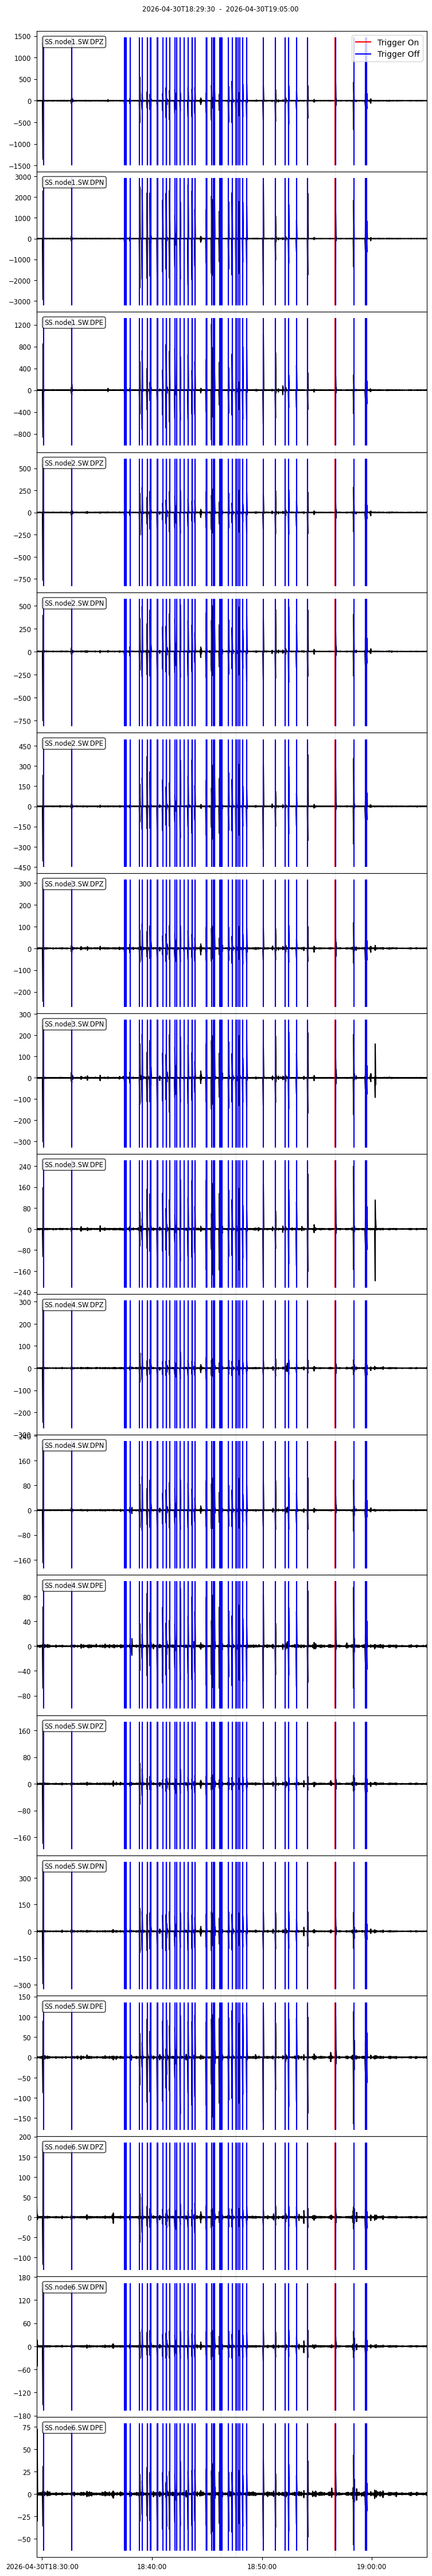

(<Figure size 800x4500 with 18 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >])

In [9]:
# Visual QC of detected event windows.
plot_stream_with_event_markers(
    st_detect,
    df_events,
    show=True,
    shade_events=True,
)


## 7. Picker functions

For each event and station:

- AIC and Baer are applied independently to Z, N, and E.
- AR picker is applied once to the 3-component station Stream.
- A station consensus pick is declared if at least `min_votes` picker/component times fall within `pick_tolerance_s`.

For these 500 Hz, very short hammer/Betsy signals, AIC is often the most stable. Baer is retained as a diagnostic, but can trigger early on low-amplitude traces.


In [10]:
def pick_baer_aic_on_trace(tr):
    """
    Apply AIC and Baer pickers to one Trace.

    Returns
    -------
    dict
        Pick status, absolute pick times, and sample indices.
    """
    sr = float(tr.stats.sampling_rate)
    y = normalize_trace_data(tr.data)

    out = {
        "baer_time": None,
        "baer_sample": None,
        "baer_ok": False,
        "baer_error": None,
        "aic_time": None,
        "aic_sample": None,
        "aic_ok": False,
        "aic_error": None,
    }

    # AIC: usually the most reliable for these short impulsive signals.
    try:
        aic = aic_simple(y)
        iaic = int(np.argmin(aic))
        out["aic_sample"] = iaic
        out["aic_time"] = tr.stats.starttime + iaic / sr
        out["aic_ok"] = True
    except Exception as e:
        out["aic_error"] = repr(e)

    # Baer: useful diagnostic, but can trigger too early on weak traces.
    try:
        p_sample, phase_info = pk_baer(
            y,
            sr,
            max(3, int(0.006 * sr)),   # tdownmax ~6 ms
            max(8, int(0.025 * sr)),   # tupevent ~25 ms
            3.0,
            6.0,
            max(5, int(0.010 * sr)),   # preset ~10 ms
            max(5, int(0.015 * sr)),   # p_dur ~15 ms
        )
        if p_sample is not None and 0 <= p_sample < len(y):
            out["baer_sample"] = int(p_sample)
            out["baer_time"] = tr.stats.starttime + p_sample / sr
            out["baer_ok"] = True
    except Exception as e:
        out["baer_error"] = repr(e)

    return out


def try_ar_pick_short_station(tr_z, tr_n, tr_e, f1=10.0, f2=150.0):
    """
    Apply ObsPy ar_pick to a 3-component station window.

    Parameters are shortened for 500 Hz, <0.3 s active-source signals.
    Returns AR P and S pick times in seconds relative to trace start.
    """
    sr = float(tr_z.stats.sampling_rate)
    npts = min(tr_z.stats.npts, tr_n.stats.npts, tr_e.stats.npts)

    p_ar, s_ar = ar_pick(
        tr_z.data[:npts].astype(float),
        tr_n.data[:npts].astype(float),
        tr_e.data[:npts].astype(float),
        sr,
        f1,
        f2,
        0.04,   # lta_p: 40 ms
        0.008,  # sta_p: 8 ms
        0.06,   # lta_s: 60 ms
        0.012,  # sta_s: 12 ms
        2,      # m_p
        4,      # m_s
        0.02,   # l_p: 20 ms
        0.04,   # l_s: 40 ms
        True,
    )

    return p_ar, s_ar


In [11]:
def consensus_pick_for_station(
    picks_by_comp,
    tr_z,
    p_ar=None,
    s_ar=None,
    pick_tolerance_s=0.02,
    min_votes=2,
    min_weight=None,
    include_ar_s=False,
    baer_weight=1.0 / 3.0,
    mute_seconds=0.20,
):
    """
    Declare a station pick if enough weighted candidate picks cluster in time.

    Candidate picks include:
      - AIC on Z/N/E, weight 1
      - Baer on Z/N/E, weight baer_weight, default 1/3
      - AR P on ZNE, weight 1
      - optionally AR S on ZNE, weight 1

    Picks earlier than mute_seconds after tr_z.stats.starttime receive weight 0.
    This is useful when Baer/AIC trigger spuriously at the start of short windows.

    Parameters
    ----------
    pick_tolerance_s : float
        Half-width of clustering window in seconds.

    min_votes : int
        Backward-compatible unweighted minimum. Used only if min_weight is None.

    min_weight : float or None
        Weighted threshold for accepting a cluster. If None, uses float(min_votes).

    baer_weight : float
        Weight assigned to Baer picks.

    mute_seconds : float
        Picks before this relative time get zero weight.
    """
    if min_weight is None:
        min_weight = float(min_votes)

    candidates = []

    def add_candidate(method, component, time, weight):
        time = obspy.UTCDateTime(time)
        relative_s = time - tr_z.stats.starttime

        if relative_s < mute_seconds:
            weight = 0.0

        candidates.append({
            "method": method,
            "component": component,
            "time": time,
            "relative_s": relative_s,
            "weight": float(weight),
        })

    for comp, picks in picks_by_comp.items():

        if picks.get("aic_ok") and picks.get("aic_time") is not None:
            add_candidate(
                method="aic",
                component=comp,
                time=picks["aic_time"],
                weight=1.0,
            )

        if picks.get("baer_ok") and picks.get("baer_time") is not None:
            add_candidate(
                method="baer",
                component=comp,
                time=picks["baer_time"],
                weight=baer_weight,
            )

    if p_ar is not None:
        add_candidate(
            method="ar_p",
            component="ZNE",
            time=tr_z.stats.starttime + p_ar,
            weight=1.0,
        )

    if include_ar_s and s_ar is not None:
        add_candidate(
            method="ar_s",
            component="ZNE",
            time=tr_z.stats.starttime + s_ar,
            weight=1.0,
        )

    if len(candidates) == 0:
        return {
            "ok": False,
            "time": None,
            "relative_s": None,
            "n_votes": 0,
            "weighted_votes": 0.0,
            "methods": [],
            "components": [],
            "candidate_times": candidates,
        }

    candidates = sorted(candidates, key=lambda d: d["time"].timestamp)

    best_cluster = []
    best_weight = 0.0

    for cand in candidates:
        t0 = cand["time"]

        cluster = [
            other
            for other in candidates
            if abs(other["time"] - t0) <= pick_tolerance_s
        ]

        cluster_weight = float(sum(c["weight"] for c in cluster))

        if cluster_weight > best_weight:
            best_cluster = cluster
            best_weight = cluster_weight

    if best_weight < min_weight:
        return {
            "ok": False,
            "time": None,
            "relative_s": None,
            "n_votes": len(best_cluster),
            "weighted_votes": best_weight,
            "methods": [c["method"] for c in best_cluster],
            "components": [c["component"] for c in best_cluster],
            "candidate_times": candidates,
        }

    positive_weight_cluster = [c for c in best_cluster if c["weight"] > 0]

    if len(positive_weight_cluster) == 0:
        return {
            "ok": False,
            "time": None,
            "relative_s": None,
            "n_votes": len(best_cluster),
            "weighted_votes": best_weight,
            "methods": [c["method"] for c in best_cluster],
            "components": [c["component"] for c in best_cluster],
            "candidate_times": candidates,
        }

    # Weighted mean is more appropriate than median once votes have weights.
    times = np.array(
        [c["time"].timestamp for c in positive_weight_cluster],
        dtype=float,
    )
    weights = np.array(
        [c["weight"] for c in positive_weight_cluster],
        dtype=float,
    )

    consensus_timestamp = float(np.average(times, weights=weights))
    consensus_time = obspy.UTCDateTime(consensus_timestamp)

    return {
        "ok": True,
        "time": consensus_time,
        "relative_s": consensus_time - tr_z.stats.starttime,
        "n_votes": len(best_cluster),
        "weighted_votes": best_weight,
        "methods": [c["method"] for c in best_cluster],
        "components": [c["component"] for c in best_cluster],
        "candidate_times": candidates,
    }


## 8. Diagnostic plotting for station picks


In [12]:
def plot_station_pick_diagnostics(
    station,
    tr_z,
    tr_n,
    tr_e,
    picks_by_comp,
    p_ar=None,
    s_ar=None,
    consensus=None,
    event_idx=None,
    outfile=None,
    dpi=160,
):
    """
    Plot Z/N/E traces for one station and one event with all picker results.
    """
    traces = {"Z": tr_z, "N": tr_n, "E": tr_e}
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    for ax, comp in zip(axes, ["Z", "N", "E"]):
        tr = traces[comp]
        sr = float(tr.stats.sampling_rate)
        t = np.arange(tr.stats.npts) / sr
        y = normalize_trace_data(tr.data)

        ax.plot(t, y, color="black", linewidth=0.8, label=comp)
        picks = picks_by_comp[comp]

        if picks.get("aic_ok"):
            ax.axvline(picks["aic_sample"] / sr, color="blue", linestyle="--", linewidth=1.2, label="AIC")
        if picks.get("baer_ok"):
            ax.axvline(picks["baer_sample"] / sr, color="red", linestyle="--", linewidth=1.2, label="Baer")
        if comp == "Z" and p_ar is not None:
            ax.axvline(p_ar, color="green", linestyle="-.", linewidth=1.5, label="AR P")
        if comp == "Z" and s_ar is not None:
            ax.axvline(s_ar, color="purple", linestyle=":", linewidth=1.5, label="AR S")
        if consensus is not None and consensus.get("ok"):
            ax.axvline(consensus["relative_s"], color="orange", linestyle="-", linewidth=2.0,
                       label=f"consensus ({consensus['n_votes']} votes)")

        ax.set_ylabel(comp)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time from station event-window start [s]")
    title = f"{station}"
    if event_idx is not None:
        title = f"Event {event_idx}: {station}"
    fig.suptitle(title)
    fig.tight_layout()

    if outfile is not None:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)
        plt.close(fig)

    return fig


## 9. Run per-station picking and build consensus pick tables

Outputs:

- `picks_df`: individual AIC/Baer picks for every event/station/component
- `station_picks_df`: one consensus pick per event/station where agreement criteria are met


In [13]:
st_pick = st_detect.copy()
st_pick.detrend("simple")
st_pick.taper(max_percentage=0.001)
st_pick.filter("bandpass", **picking_bandpass)

all_picks = []
all_station_picks = []

pick_diag_dir = outdir_figs / "station_pick_diagnostics"
pick_diag_dir.mkdir(parents=True, exist_ok=True)

for event_idx, row in df_events.iterrows():

    event_start = obspy.UTCDateTime(row["on_time"]) - float(row["pretrigger_s"])
    event_end = obspy.UTCDateTime(row["off_time"]) + float(row["posttrigger_s"])

    st_event = st_pick.copy().trim(starttime=event_start, endtime=event_end, pad=False)

    datamax = safe_max_abs(st_event)
    if not np.isfinite(datamax) or datamax <= min_event_peak_amplitude:
        continue

    print(
        f"Event {event_idx}: "
        f"SNR={row['snr_rms']:.1f}, "
        f"on_time={row['on_time']}, off_time={row['off_time']}, "
        f"peak={datamax:.1f}"
    )

    for station in station_names:
        st_sta = st_event.select(station=station)

        if len(st_sta) < 3:
            print(f"  skipping {station}: fewer than 3 components")
            continue

        try:
            tr_z = st_sta.select(component="Z")[0]
            tr_n = st_sta.select(component="N")[0]
            tr_e = st_sta.select(component="E")[0]
        except IndexError:
            print(f"  skipping {station}: missing Z/N/E")
            continue

        picks_by_comp = {
            "Z": pick_baer_aic_on_trace(tr_z),
            "N": pick_baer_aic_on_trace(tr_n),
            "E": pick_baer_aic_on_trace(tr_e),
        }

        try:
            p_ar, s_ar = try_ar_pick_short_station(tr_z, tr_n, tr_e)
        except Exception as e:
            p_ar, s_ar = None, None
            print(f"  AR picker failed for {station}: {e}")

        consensus = consensus_pick_for_station(
            picks_by_comp,
            tr_z,
            p_ar=p_ar,
            s_ar=s_ar,
            pick_tolerance_s=pick_tolerance_s,
            min_votes=min_votes,
            include_ar_s=include_ar_s,
        )
        
        consensus = consensus_pick_for_station(
            picks_by_comp,
            tr_z,
            p_ar=p_ar,
            s_ar=s_ar,
            pick_tolerance_s=pick_tolerance_s,
            min_votes=min_votes,
            include_ar_s=include_ar_s,
            min_weight=2.0,
            baer_weight=1.0 / 3.0,
            mute_seconds=0.20,
        )

        diag_file = pick_diag_dir / f"event_{int(event_idx):03d}_{station}_picker_diagnostics.png"
        plot_station_pick_diagnostics(
            station,
            tr_z,
            tr_n,
            tr_e,
            picks_by_comp,
            p_ar=p_ar,
            s_ar=s_ar,
            consensus=consensus,
            event_idx=event_idx,
            outfile=diag_file,
        )

        all_station_picks.append({
            "event_idx": event_idx,
            "station": station,
            "event_on_time": row["on_time"],
            "event_off_time": row["off_time"],
            "consensus_ok": consensus["ok"],
            "consensus_time": consensus["time"],
            "consensus_relative_s": consensus["relative_s"],
            "consensus_n_votes": consensus["n_votes"],
            "consensus_methods": ",".join(consensus["methods"]),
            "consensus_components": ",".join(consensus["components"]),
            "ar_p_time": tr_z.stats.starttime + p_ar if p_ar is not None else None,
            "ar_s_time": tr_z.stats.starttime + s_ar if s_ar is not None else None,
            "ar_p_relative_s": p_ar,
            "ar_s_relative_s": s_ar,
        })

        for comp, picks in picks_by_comp.items():
            all_picks.append({
                "event_idx": event_idx,
                "station": station,
                "component": comp,
                "event_on_time": row["on_time"],
                "event_off_time": row["off_time"],
                "aic_time": picks["aic_time"],
                "aic_sample": picks["aic_sample"],
                "aic_ok": picks["aic_ok"],
                "aic_error": picks.get("aic_error"),
                "baer_time": picks["baer_time"],
                "baer_sample": picks["baer_sample"],
                "baer_ok": picks["baer_ok"],
                "baer_error": picks.get("baer_error"),
            })

picks_df = pd.DataFrame(all_picks)
station_picks_df = pd.DataFrame(all_station_picks)

picks_csv = outdir_tables / "geopark_individual_method_picks.csv"
station_picks_csv = outdir_tables / "geopark_station_consensus_picks.csv"

picks_df.to_csv(picks_csv, index=False)
station_picks_df.to_csv(station_picks_csv, index=False)

print(f"Wrote {picks_csv}")
print(f"Wrote {station_picks_csv}")

display(station_picks_df)


Event 0: SNR=178.2, on_time=2026-04-30 18:30:06.536000, off_time=2026-04-30 18:30:07.084000, peak=2849.8
Event 4: SNR=11.6, on_time=2026-04-30 18:37:31.380000, off_time=2026-04-30 18:37:31.630000, peak=191.1
Event 6: SNR=15.1, on_time=2026-04-30 18:37:37.128000, off_time=2026-04-30 18:37:37.280000, peak=104.2
Event 7: SNR=11.4, on_time=2026-04-30 18:37:37.608000, off_time=2026-04-30 18:37:37.754000, peak=130.5
Event 8: SNR=14.7, on_time=2026-04-30 18:38:01.252000, off_time=2026-04-30 18:38:01.414000, peak=123.5
Event 9: SNR=50.8, on_time=2026-04-30 18:38:52.322000, off_time=2026-04-30 18:38:52.650000, peak=2660.7
Event 10: SNR=36.2, on_time=2026-04-30 18:39:06.852000, off_time=2026-04-30 18:39:07.082000, peak=2309.3
Event 11: SNR=135.0, on_time=2026-04-30 18:39:33.496000, off_time=2026-04-30 18:39:33.948000, peak=2378.7
Event 13: SNR=43.9, on_time=2026-04-30 18:39:50.422000, off_time=2026-04-30 18:39:50.736000, peak=2167.8
Event 14: SNR=27.0, on_time=2026-04-30 18:39:54.006000, off_tim

,event_idx,station,event_on_time,event_off_time,consensus_ok,consensus_time,consensus_relative_s,consensus_n_votes,consensus_methods,consensus_components,ar_p_time,ar_s_time,ar_p_relative_s,ar_s_relative_s
0,0,node1,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.883333Z,0.597333,3,"aic,ar_p,aic","Z,ZNE,E",2026-04-30T18:30:06.884000Z,2026-04-30T18:30:06.894000Z,0.598,0.608
1,0,node2,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.900462Z,0.614462,5,"ar_p,aic,aic,aic,baer","ZNE,Z,N,E,E",2026-04-30T18:30:06.894000Z,2026-04-30T18:30:06.900000Z,0.608,0.614
2,0,node3,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.903231Z,0.617231,5,"ar_p,baer,aic,aic,aic","ZNE,N,Z,N,E",2026-04-30T18:30:06.894000Z,2026-04-30T18:30:06.910000Z,0.608,0.624
3,0,node4,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.906923Z,0.620923,5,"ar_p,aic,aic,aic,baer","ZNE,Z,N,E,Z",2026-04-30T18:30:06.898000Z,2026-04-30T18:30:06.910000Z,0.612,0.624
4,0,node5,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.914533Z,0.628533,7,"ar_p,aic,baer,aic,baer,baer,aic","ZNE,Z,Z,N,N,E,E",2026-04-30T18:30:06.902000Z,2026-04-30T18:30:06.286000Z,0.616,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,68,node2,2026-04-30 18:59:31.520,2026-04-30 18:59:31.806,True,2026-04-30T18:59:31.668154Z,0.398154,5,"ar_p,aic,baer,aic,aic","ZNE,Z,Z,N,E",2026-04-30T18:59:31.658000Z,2026-04-30T18:59:31.668000Z,0.388,0.398
332,68,node3,2026-04-30 18:59:31.520,2026-04-30 18:59:31.806,True,2026-04-30T18:59:31.676001Z,0.406001,7,"ar_p,baer,baer,aic,aic,aic,baer","ZNE,Z,N,Z,N,E,E",2026-04-30T18:59:31.666000Z,2026-04-30T18:59:31.678000Z,0.396,0.408
333,68,node4,2026-04-30 18:59:31.520,2026-04-30 18:59:31.806,True,2026-04-30T18:59:31.682000Z,0.412000,6,"ar_p,aic,baer,aic,aic,baer","ZNE,Z,Z,N,E,E",2026-04-30T18:59:31.678000Z,2026-04-30T18:59:31.690000Z,0.408,0.420
334,68,node5,2026-04-30 18:59:31.520,2026-04-30 18:59:31.806,True,2026-04-30T18:59:31.688714Z,0.418714,6,"aic,ar_p,baer,aic,baer,aic","Z,ZNE,Z,N,E,E",2026-04-30T18:59:31.686000Z,2026-04-30T18:59:31.706000Z,0.416,0.436


## 10. Trim fixed-length event windows from earliest station consensus pick

For each event, find the earliest successful station consensus pick. The exported event window is:

```text
start = earliest_station_consensus_pick - event_pre_pick_s
end   = start + event_length_s
```

Use `st_raw` if you want archival event MiniSEED. Use `st_pick` if you want filtered event cuts for plotting/analysis. The code below writes archival cuts from `st_raw` but plots the same event windows.


In [14]:
def trim_events_from_consensus_picks(
    st,
    station_picks_df,
    pre_pick_s=0.10,
    event_length_s=0.50,
    only_consensus_ok=True,
):
    """
    Trim fixed-length event Streams using earliest station consensus pick per event.
    """
    event_streams = {}
    event_windows = []

    dfp = station_picks_df.copy()
    if only_consensus_ok:
        dfp = dfp[dfp["consensus_ok"] == True]

    for event_idx, group in dfp.groupby("event_idx"):
        pick_times = []
        for t in group["consensus_time"]:
            if t is None or str(t) in ("NaT", "None", "nan"):
                continue
            pick_times.append(obspy.UTCDateTime(t))

        if len(pick_times) == 0:
            continue

        reference_time = min(pick_times)
        event_start = reference_time - pre_pick_s
        event_end = event_start + event_length_s

        st_event = st.copy().trim(starttime=event_start, endtime=event_end, pad=True, fill_value=0)
        event_streams[event_idx] = st_event

        event_windows.append({
            "event_idx": event_idx,
            "reference_time": reference_time,
            "event_start": event_start,
            "event_end": event_end,
            "pre_pick_s": pre_pick_s,
            "event_length_s": event_length_s,
            "n_station_picks": len(group),
            "stations": ",".join(sorted(group["station"].astype(str).unique())),
        })

    return event_streams, pd.DataFrame(event_windows)


event_streams, event_windows_df = trim_events_from_consensus_picks(
    st_raw,
    station_picks_df,
    pre_pick_s=event_pre_pick_s,
    event_length_s=event_length_s,
)

event_windows_csv = outdir_tables / "geopark_event_windows.csv"
event_windows_df.to_csv(event_windows_csv, index=False)

print(f"Wrote {event_windows_csv}")
display(event_windows_df)


Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/tables/geopark_event_windows.csv


,event_idx,reference_time,event_start,event_end,pre_pick_s,event_length_s,n_station_picks,stations
0,0,2026-04-30T18:30:06.883333Z,2026-04-30T18:30:06.783333Z,2026-04-30T18:30:07.283333Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
1,4,2026-04-30T18:37:31.369454Z,2026-04-30T18:37:31.269454Z,2026-04-30T18:37:31.769454Z,0.1,0.5,5,"node1,node2,node3,node4,node5"
2,6,2026-04-30T18:37:37.123000Z,2026-04-30T18:37:37.023000Z,2026-04-30T18:37:37.523000Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
3,7,2026-04-30T18:37:37.614616Z,2026-04-30T18:37:37.514616Z,2026-04-30T18:37:38.014616Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
4,8,2026-04-30T18:38:01.250286Z,2026-04-30T18:38:01.150286Z,2026-04-30T18:38:01.650286Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
5,9,2026-04-30T18:38:52.487500Z,2026-04-30T18:38:52.387500Z,2026-04-30T18:38:52.887500Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
6,10,2026-04-30T18:39:06.898500Z,2026-04-30T18:39:06.798500Z,2026-04-30T18:39:07.298500Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
7,11,2026-04-30T18:39:33.748500Z,2026-04-30T18:39:33.648500Z,2026-04-30T18:39:34.148500Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
8,13,2026-04-30T18:39:50.559692Z,2026-04-30T18:39:50.459692Z,2026-04-30T18:39:50.959692Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"
9,14,2026-04-30T18:39:54.007692Z,2026-04-30T18:39:53.907692Z,2026-04-30T18:39:54.407692Z,0.1,0.5,6,"node1,node2,node3,node4,node5,node6"


## 11. Plot event cuts with station-specific consensus picks

These figures show one component at a time, with each station's own consensus pick marked by an orange dot and short orange bar.


In [15]:
def plot_event_stream_with_station_consensus(
    st_event,
    station_picks_df,
    event_idx,
    component="Z",
    outfile=None,
    normalize=True,
    scale=1.0,
    dpi=160,
):
    """
    Plot one component for all stations in an event Stream, with each station's
    own consensus pick time superimposed.
    """
    st_comp = st_event.select(component=component)

    if len(st_comp) == 0:
        print(f"No {component} traces for event {event_idx}")
        return None

    picks = station_picks_df[
        (station_picks_df["event_idx"] == event_idx)
        & (station_picks_df["consensus_ok"] == True)
    ].copy()

    t0 = min(tr.stats.starttime for tr in st_event)
    traces = sorted(st_comp, key=lambda tr: tr.stats.station)

    fig, ax = plt.subplots(figsize=(12, 7))

    for i, tr in enumerate(traces):
        station = tr.stats.station
        y = normalize_trace_data(tr.data) if normalize else tr.data.astype(float)
        t = np.arange(tr.stats.npts) * tr.stats.delta + (tr.stats.starttime - t0)

        ax.plot(t, y * scale + i, color="black", linewidth=0.7)
        ax.text(t[-1], i, f" {tr.id}", va="center", fontsize=8)

        station_pick = picks[picks["station"] == station]
        if len(station_pick) > 0:
            pick_time = obspy.UTCDateTime(station_pick.iloc[0]["consensus_time"])
            pick_rel = pick_time - t0

            # Dot at trace centre.
            ax.plot(
                pick_rel,
                i,
                marker="o",
                markersize=8,
                color="orange",
                markeredgecolor="black",
                linestyle="None",
                label="station consensus pick" if i == 0 else None,
            )

            # Short vertical marker in data coordinates, centred on trace.
            ax.plot(
                [pick_rel, pick_rel],
                [i - 0.32, i + 0.32],
                color="orange",
                linewidth=2.5,
            )

    ax.set_title(f"Event {int(event_idx):03d}: {component}-component station consensus picks")
    ax.set_xlabel("Time from event window start [s]")
    ax.set_ylabel("Station / trace")
    ax.set_yticks([])
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="upper right")

    fig.tight_layout()

    if outfile:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)
        plt.close(fig)

    return fig


## 12. Save event MiniSEED files and QC figures

This writes:

```text
processed_geopark/events_mseed/event_000.mseed
processed_geopark/figures/event_station_consensus/event_000_Z_station_consensus.png
processed_geopark/tables/geopark_station_consensus_picks.csv
processed_geopark/tables/geopark_event_windows.csv
```


In [16]:
consensus_fig_dir = outdir_figs / "event_station_consensus"
consensus_fig_dir.mkdir(parents=True, exist_ok=True)

# Save tables again here so this output cell is self-contained.
station_picks_df.to_csv(outdir_tables / "geopark_station_consensus_picks.csv", index=False)
event_windows_df.to_csv(outdir_tables / "geopark_event_windows.csv", index=False)

for _, row in event_windows_df.iterrows():
    event_idx = int(row["event_idx"])
    st_event = event_streams[event_idx]

    mseed_file = outdir_events_mseed / f"event_{event_idx:03d}.mseed"
    st_event.write(str(mseed_file), format="MSEED")

    for component in ["Z", "N", "E"]:
        fig_file = consensus_fig_dir / f"event_{event_idx:03d}_{component}_station_consensus.png"
        plot_event_stream_with_station_consensus(
            st_event,
            station_picks_df,
            event_idx=event_idx,
            component=component,
            outfile=fig_file,
            normalize=True,
            scale=0.8,
        )

    print(f"Wrote {mseed_file}")


Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/events_mseed/event_000.mseed
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/events_mseed/event_004.mseed
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/events_mseed/event_006.mseed
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/events_mseed/event_007.mseed
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/events_mseed/event_008.mseed
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed/events_mseed/event_009.mseed
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoP

## 13. Outputs for the source-function notebook

This segmentation notebook intentionally stops here. It writes only event and pick products under `outdir`:

```text
processed_geopark/
  events_mseed/event_*.mseed
  tables/geopark_station_geometry.csv
  tables/geopark_detected_events.csv
  tables/geopark_individual_method_picks.csv
  tables/geopark_station_consensus_picks.csv
  tables/geopark_event_windows.csv
  figures/...
```

The next notebook, `20_geopark_source_function_analysis.ipynb`, should read those products and handle Betsy/hammer comparison, consensus-pick stacks, cross-correlation stacks, empirical STF export, and optional SEG-Y export.
